Nama

---

**Marissa Auditia Khoironisa**


Menjelaskan tujuan analisis, konteks data, dan pertanyaan yang ingin dijawab

  ## **Pemahaman Masalah & Tujuan Analisis**
  

---


  Perusahaan parfum ingin memahami faktor-faktor apa saja yang paling memengaruhi potensi pendapatan (`Revenue_Potential`) sebuah produk. Dalam industri yang sangat kompetitif ini, kemampuan untuk memprediksi produk mana yang akan menghasilkan pendapatan lebih tinggi adalah kunci untuk mengoptimalkan strategi pemasaran, manajemen inventaris, dan pengembangan produk.

**Tujuan Analisis:**

---

1.  **Prediksi:** Membangun model *Machine Learning* (ML) dan *Artificial Neural Network* (ANN) yang akurat untuk memprediksi `Revenue_Potential` berdasarkan berbagai fitur produk.
2.  **Analisis:** Mengidentifikasi fitur-fitur yang paling berpengaruh terhadap potensi pendapatan.
3.  **Perbandingan:** Membandingkan performa model ML (dari Mini Project 1) dengan model ANN yang dibangun, serta menganalisis kelebihan dan kekurangan masing-masing.
4.  **Implementasi:** Menyediakan antarmuka (*deployment*) melalui aplikasi Streamlit yang memungkinkan pengguna untuk memasukkan data produk dan mendapatkan prediksi pendapatan secara interaktif.

# **Praproses Data & Feature Engineering**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **Praproses Data & Feature Engineering**

## **Load Dataset**

In [ ]:
!kaggle datasets download zohairbaloch/global-perfume-e-commerce-analytics-dataset

Dataset URL: https://www.kaggle.com/datasets/zohairbaloch/global-perfume-e-commerce-analytics-dataset
License(s): unknown
global-perfume-e-commerce-analytics-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -o -q /content/global-perfume-e-commerce-analytics-dataset.zip

In [ ]:
df=pd.read_csv('/content/Perfume_Market_Intelligence_Dataset.csv')
df.head()

,Brand,Product,Gender,Product_Type,Price,Sold,Available,Revenue_Potential,Demand_Score,Price_Category,Market_Segment,Sales_Performance,Brand_Popularity,Country,Inventory_Status,Stock_Turnover,Revenue_Rank
0,Paco Rabanne,Paco Rabanne Invictus 3.4 oz EDT Sporty Men's ...,Men,EDT,39.99,118.0,10.0,4718.82,94.597,Mid-Range,Premium,High Seller,High,United States,Medium Stock,Fast,Others
1,Lucianno,Lucianno California Vibe M 100ml Boxed,Men,Unknown,66.00,21.0,10.0,1386.00,34.500,Mid-Range,Premium,Medium Seller,Low,Canada,Medium Stock,Slow,Others
2,BHARARA,BHARARA KING PURE PARFUM BY BHARARA 3.4 FOR ME...,Men,Parfum,71.49,31.0,4.0,2216.19,43.147,Mid-Range,Premium,Medium Seller,Low,United States,Low Stock,Fast,Others
3,Branded,*Perfume Para Hombre Con Feromonas De Atraer M...,Men,Unknown,17.99,1.0,13.0,17.99,6.097,Budget,Mass Market,Low Seller,Low,United States,Medium Stock,Slow,Others
4,Thierry Mugler,Alien by Thierry Mugler 3 oz EDP Perfume for W...,Women,EDP,85.56,953.0,0.0,81538.68,692.768,Luxury,Luxury,High Seller,Medium,United States,Low Stock,Fast,Top 10%


In [ ]:
df.shape

(1998, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              1996 non-null   object 
 1   Product            1998 non-null   object 
 2   Gender             1998 non-null   object 
 3   Product_Type       1998 non-null   object 
 4   Price              1998 non-null   float64
 5   Sold               1998 non-null   float64
 6   Available          1998 non-null   float64
 7   Revenue_Potential  1998 non-null   float64
 8   Demand_Score       1998 non-null   float64
 9   Price_Category     1998 non-null   object 
 10  Market_Segment     1998 non-null   object 
 11  Sales_Performance  1998 non-null   object 
 12  Brand_Popularity   1998 non-null   object 
 13  Country            1998 non-null   object 
 14  Inventory_Status   1998 non-null   object 
 15  Stock_Turnover     1998 non-null   object 
 16  Revenue_Rank       1998 

### **MISSING VALUE**

In [ ]:
df.isnull().sum()

,0
Brand,2
Product,0
Gender,0
Product_Type,0
Price,0
Sold,0
Available,0
Revenue_Potential,0
Demand_Score,0
Price_Category,0


In [ ]:
df['Brand'] = df['Brand'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
Brand,0
Product,0
Gender,0
Product_Type,0
Price,0
Sold,0
Available,0
Revenue_Potential,0
Demand_Score,0
Price_Category,0


In [ ]:
df.duplicated().sum()
print(f'Shape setelah drop duplikat: {df.shape}')

Shape setelah drop duplikat: (1998, 17)


In [ ]:
df.columns.tolist()

['Brand',
 'Product',
 'Gender',
 'Product_Type',
 'Price',
 'Sold',
 'Available',
 'Revenue_Potential',
 'Demand_Score',
 'Price_Category',
 'Market_Segment',
 'Sales_Performance',
 'Brand_Popularity',
 'Country',
 'Inventory_Status',
 'Stock_Turnover',
 'Revenue_Rank']

In [ ]:
df.describe()

,Price,Sold,Available,Revenue_Potential,Demand_Score
count,1998.000000,1998.000000,1998.000000,1.998000e+03,1998.000000
mean,43.173769,626.139640,18.236737,1.986833e+04,451.249878
std,32.632128,2458.463389,53.685666,7.691445e+04,1720.077308
min,1.990000,0.000000,0.000000,0.000000e+00,3.700000
25%,21.957500,14.000000,3.000000,5.113175e+02,24.619000
50%,33.995000,49.000000,9.000000,1.811520e+03,51.595500
75%,53.987500,278.750000,10.000000,9.446993e+03,207.022750
max,299.990000,54052.000000,842.000000,1.420246e+06,37843.567000


In [ ]:
# Drop kolom yang memiliki nilai unik tinggi dan tidak relevan

df_clean = df.copy()

drop_cols = ['Brand', 'Product', 'Revenue_Rank', 'Demand_Score']
df_clean.drop(drop_cols, axis=1, inplace=True)
df_clean.head()

,Gender,Product_Type,Price,Sold,Available,Revenue_Potential,Price_Category,Market_Segment,Sales_Performance,Brand_Popularity,Country,Inventory_Status,Stock_Turnover
0,Men,EDT,39.99,118.0,10.0,4718.82,Mid-Range,Premium,High Seller,High,United States,Medium Stock,Fast
1,Men,Unknown,66.00,21.0,10.0,1386.00,Mid-Range,Premium,Medium Seller,Low,Canada,Medium Stock,Slow
2,Men,Parfum,71.49,31.0,4.0,2216.19,Mid-Range,Premium,Medium Seller,Low,United States,Low Stock,Fast
3,Men,Unknown,17.99,1.0,13.0,17.99,Budget,Mass Market,Low Seller,Low,United States,Medium Stock,Slow
4,Women,EDP,85.56,953.0,0.0,81538.68,Luxury,Luxury,High Seller,Medium,United States,Low Stock,Fast


In [ ]:
df_clean.columns.to_list()

['Gender',
 'Product_Type',
 'Price',
 'Sold',
 'Available',
 'Revenue_Potential',
 'Price_Category',
 'Market_Segment',
 'Sales_Performance',
 'Brand_Popularity',
 'Country',
 'Inventory_Status',
 'Stock_Turnover']

In [ ]:
num_cols = df_clean.select_dtypes(include='number').columns
cat_cols = df_clean.select_dtypes(include='object').columns

print(f'Kolom numerikal: {num_cols}')
print(f'Kolom kategorikal: {cat_cols}')

Kolom numerikal: Index(['Price', 'Sold', 'Available', 'Revenue_Potential'], dtype='object')
Kolom kategorikal: Index(['Gender', 'Product_Type', 'Price_Category', 'Market_Segment',
       'Sales_Performance', 'Brand_Popularity', 'Country', 'Inventory_Status',
       'Stock_Turnover'],
      dtype='object')


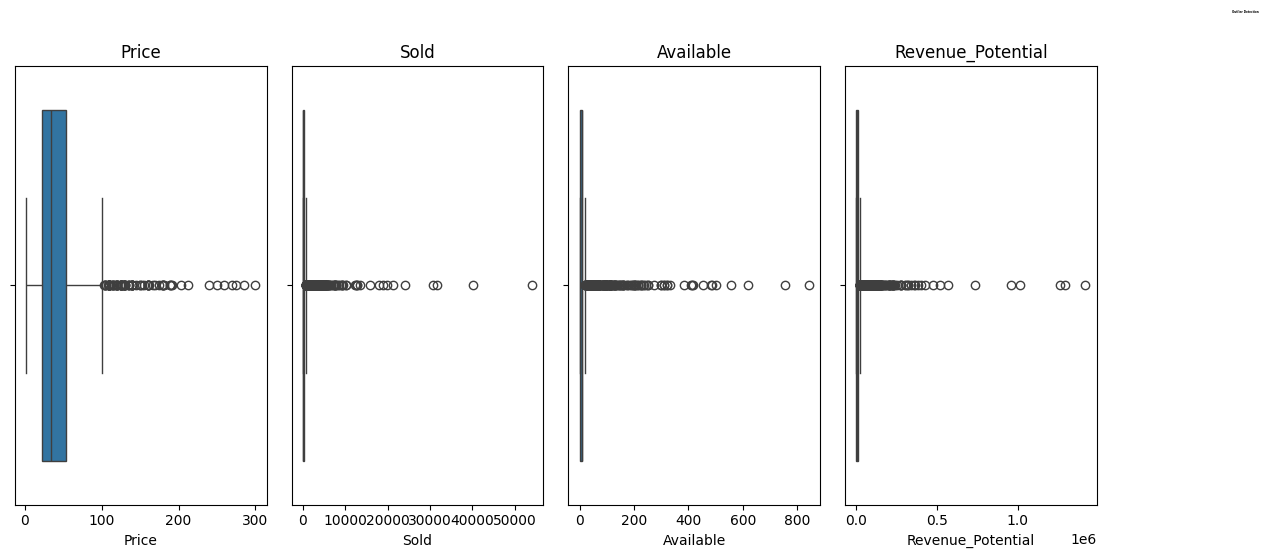

In [ ]:
plt.figure(figsize=(25,20))

plt.suptitle(
    'Outlier Detection',
    fontsize=2,
    fontweight='bold',
    y=1
)

for i, col in enumerate(num_cols, 1):
    plt.subplot(4,9,i)
    sns.boxplot(x=df_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## **HANDLING OUTLIERS**

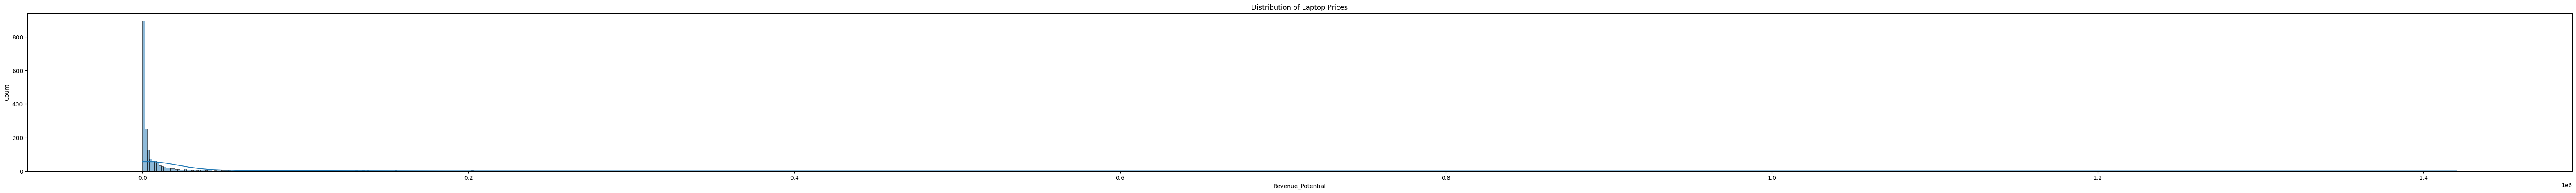

In [ ]:
plt.figure(figsize=(80,5))
sns.histplot(df_clean['Revenue_Potential'], kde=True)

plt.title('Distribution of Laptop Prices')
plt.xlabel('Revenue_Potential')
plt.show()

In [ ]:
#Mencari outlier menggunakan Tukey rule

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outlier")

Price: 90 outlier
Sold: 294 outlier
Available: 210 outlier
Revenue_Potential: 294 outlier


Dari hasil di atas terdapat outlier yang cukup banyak, dan tidak bisa dihillangkan karena pada realitanya outlier sering ditemui dalam penjualan.

## **ENCODING**

In [ ]:
df_clean['Product_Type'] = df_clean['Product_Type'].replace({
    'Eau De Toilette': 'EDT',
    'Parfum' : 'EDP'
})

df_clean["Product_Type"].value_counts()

,count
Product_Type,
EDP,999
EDT,612
Cologne,199
Unknown,188


In [ ]:
df_clean[df_clean['Product_Type'] == 'Unknown']['Product_Type'].value_counts()

,count
Product_Type,
Unknown,188


In [ ]:
# Ubah ke huruf kecil
product = df_clean['Product_Type'].str.lower()

# Klasifikasi berdasarkan kata kunci
df_clean.loc[
    product.str.contains(r'eau\s+de\s+(parfum|parfume|perfume)', na=False),
    'Product_Type'
] = 'EDP'

df_clean.loc[
    product.str.contains(r'eau\s+de\s+toilette', na=False),
    'Product_Type'
] = 'EDT'

df_clean.loc[
    product.str.contains(r'eau\s+de\s+cologne', regex=True, na=False),
    'Product_Type'
] = 'Cologne'

# Jika mengandung "eau" tetapi belum masuk kategori di atas
mask_unknown = (
    product.str.contains('eau', na=False) & ~df_clean['Product_Type'].isin(['EDP', 'EDT', 'Cologne'])
)

df_clean.loc[mask_unknown, 'Product_Type'] = 'Unknown'

print(df_clean['Product_Type'].value_counts())

Product_Type
EDP        999
EDT        612
Cologne    199
Unknown    188
Name: count, dtype: int64


In [ ]:
# Pisah X dan y
X = df_clean.drop('Revenue_Potential', axis=1)
y = df_clean['Revenue_Potential']



In [ ]:
ordinal_mappings = {
    'Price_Category': {'Budget': 0, 'Mid-Range': 1, 'Luxury': 2},
    'Market_Segment': {'Mass Market': 0, 'Premium': 1, 'Luxury': 2},
    'Sales_Performance': {'Low Seller': 0, 'Medium Seller': 1, 'High Seller': 2},
    'Brand_Popularity': {'Low': 0, 'Medium': 1, 'High': 2},
    'Inventory_Status': {'Low Stock': 0, 'Medium Stock': 1, 'High Stock': 2},
    'Stock_Turnover': {'Slow': 0, 'Moderate': 1, 'Fast': 2}
}

for col, mapping in ordinal_mappings.items():
    X[col] = X[col].map(mapping)

# Cek hasil encoding ordinal
print("Hasil encoding ordinal (5 data pertama):")
print(X[list(ordinal_mappings.keys())].head())

Hasil encoding ordinal (5 data pertama):
   Price_Category  Market_Segment  Sales_Performance  Brand_Popularity  \
0               1               1                  2                 2   
1               1               1                  1                 0   
2               1               1                  1                 0   
3               0               0                  0                 0   
4               2               2                  2                 1   

   Inventory_Status  Stock_Turnover  
0                 1               2  
1                 1               0  
2                 0               2  
3                 1               0  
4                 0               2  


In [ ]:
# Kolom nominal yang TIDAK memiliki urutan
nominal_cols = ['Gender', 'Product_Type', 'Country']

# Gunakan pd.get_dummies dengan drop_first=True untuk menghindari dummy trap/kolinearitas sempurna
X_encoded = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

print(f"\nJumlah fitur sebelum encoding: {X.shape[1]}")
print(f"Jumlah fitur setelah encoding: {X_encoded.shape[1]}")
print(f"Nama fitur baru: {X_encoded.columns.tolist()}")


Jumlah fitur sebelum encoding: 12
Jumlah fitur setelah encoding: 26
Nama fitur baru: ['Price', 'Sold', 'Available', 'Price_Category', 'Market_Segment', 'Sales_Performance', 'Brand_Popularity', 'Inventory_Status', 'Stock_Turnover', 'Gender_Women', 'Product_Type_EDP', 'Product_Type_EDT', 'Product_Type_Unknown', 'Country_Bulgaria', 'Country_Canada', 'Country_China', 'Country_Estados Unidos', 'Country_Hong Kong', 'Country_India', 'Country_Israel', 'Country_Japan', 'Country_Pakistan', 'Country_Poland', 'Country_Portugal', 'Country_Taiwan', 'Country_United States']


### **P-VALUE**

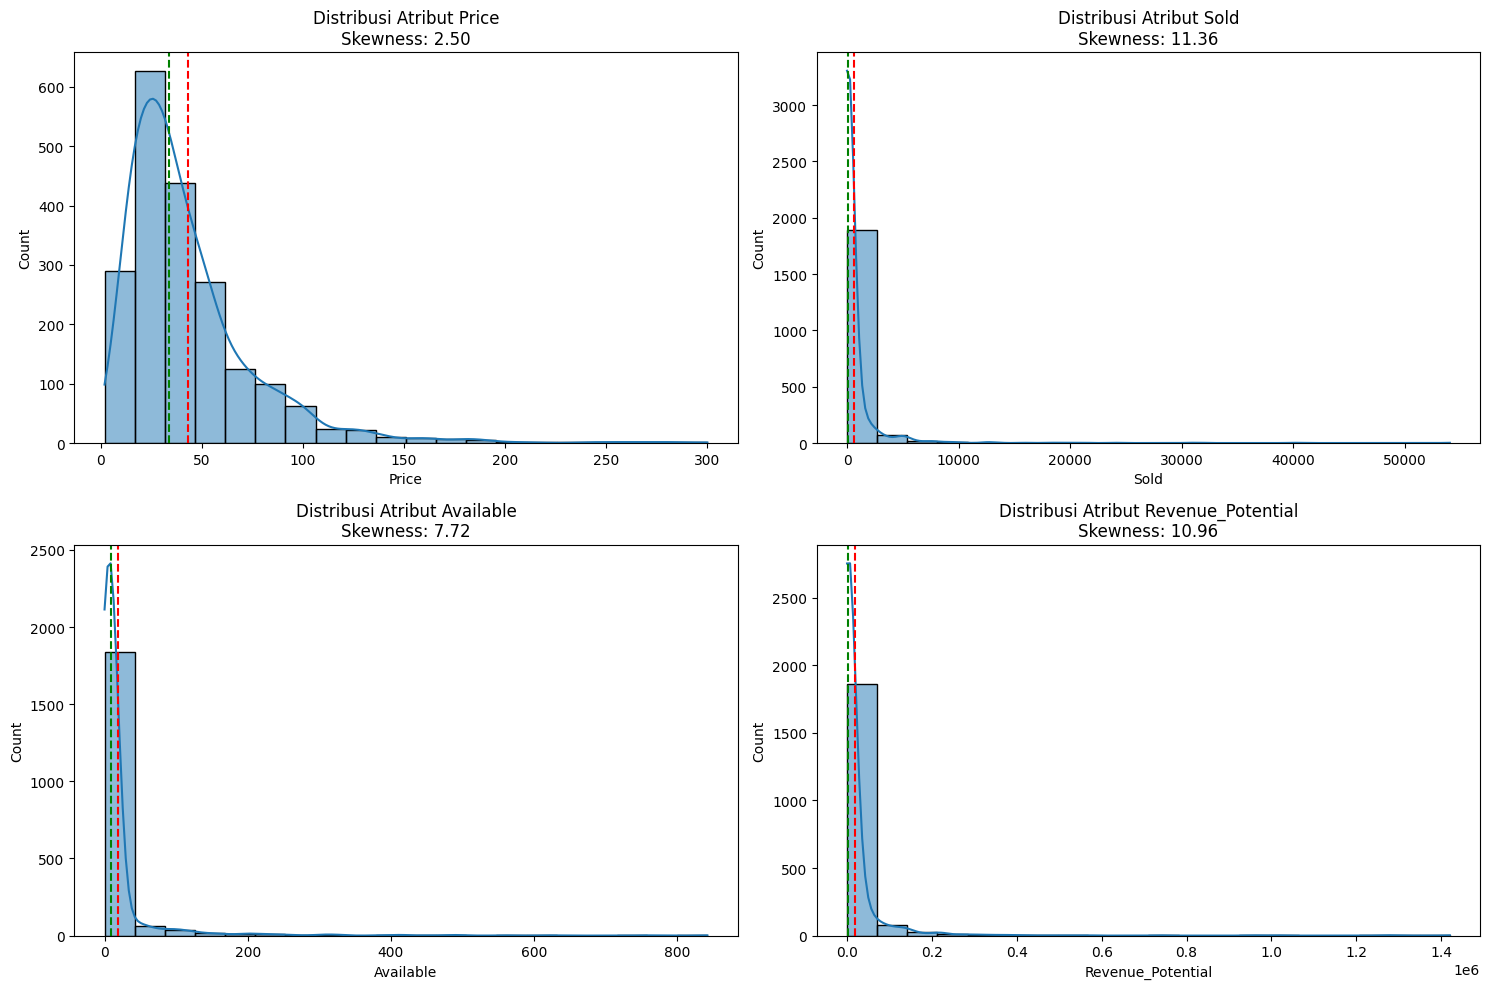

In [ ]:
#Melihat skewness kolom
num_cols = df_clean.select_dtypes(include='number').columns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df_clean, x=col, ax=axes[i], kde=True, bins=20) # Use axes[i]
    axes[i].axvline(df_clean[col].mean(), color='r', linestyle='--')
    axes[i].axvline(df_clean[col].median(), color='g', linestyle='--')
    axes[i].set_title(f'Distribusi Atribut {col}\nSkewness: {df_clean[col].skew():.2f}')

plt.tight_layout() # Adjust layout to prevent overlaps
plt.show()

In [ ]:
from scipy import stats

Kolom_distribusi_normal = []
Kolom_distribusi_tidak_normal = []
print("=== Hasil D’Agostino’s K^2 Test ===")
for col in num_cols:
    res = stats.normaltest(df[col])
    if res.pvalue > 0.05:
        Kolom_distribusi_normal.append(col)
        print(f"Kolom {col} berdistribusi secara normal")
    else:
        Kolom_distribusi_tidak_normal.append(col)
        print(f"{col} tidak berdistribusi normal")
        print(f"p-value {col}: {res.pvalue}")

In [ ]:
plt.figure(figsize=(20,18))

sns.heatmap(
    df_clean[num_cols].corr(method='spearman'),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Correlation Heatmap of Numerical Features',
    fontsize=16,
    fontweight='bold',
    y=1
)

plt.show()

## **FEATURE ENGINEERING**

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()

vif_df['Feature'] = X_encoded.columns

X_encoded_numeric = X_encoded.astype('float')

vif_df['VIF'] = [
    variance_inflation_factor(X_encoded_numeric.values, i)
    for i in range(X_encoded_numeric.shape[1])
]

vif_df.sort_values(
    by='VIF',
    ascending=False
).head(10)

#**Exploratory Data Analysis (EDA)**

In [ ]:
# 4.1 Distribusi target
plt.figure(figsize=(10,6))
sns.histplot(y, kde=True)
plt.title('Distribusi Revenue_Potential')
plt.xlabel('Revenue Potential')
plt.show()

# 4.2 Scatter Sold vs Revenue
plt.figure(figsize=(10,6))
sns.scatterplot(x=df_clean['Sold'], y=df_clean['Revenue_Potential'])
plt.title('Sold vs Revenue_Potential')
plt.show()

# 4.3 Boxplot Revenue per Price_Category (sebelum one-hot)
plt.figure(figsize=(10,6))
sns.boxplot(x='Price_Category', y='Revenue_Potential', data=df_clean)
plt.title('Revenue by Price Category')
plt.show()

# 4.4 Barplot rata-rata Revenue per Market_Segment
plt.figure(figsize=(10,6))
df_clean.groupby('Market_Segment')['Revenue_Potential'].mean().sort_values().plot(kind='bar')
plt.title('Rata-rata Revenue per Market Segment')
plt.ylabel('Rata-rata Revenue Potential')
plt.show()

# 4.5 Heatmap korelasi numerik
plt.figure(figsize=(8,6))
sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

## **SCALLING**

In [ ]:
scaler = RobustScaler()

X_train_sc = scaler.fit_transform(X_train)  # fit HANYA pada train
X_val_sc   = scaler.transform(X_val)        # transform val pakai parameter train
X_test_sc  = scaler.transform(X_test)       # transform test pakai parameter train

print('Scaling selesai.')
print(f'X_train_sc shape: {X_train_sc.shape}')
print(f'X_val_sc shape: {X_val_sc.shape}')
print(f'X_test_sc shape: {X_test_sc.shape}')

# **Model Development**

# **BUILD ANN**

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_encoded, y,
    test_size=0.15,
    random_state=42
    )

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2,
    random_state=42
    )

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_val: {X_val.shape}')
print(f'Shape of X_test: {X_test.shape}')

# Model Sequential API

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.initializers import HeNormal, GlorotNormal
from tensorflow.keras.regularizers import l2

seed = 42
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)


In [ ]:

model = Sequential([
    Input(shape=(26, ), name='input_layer'),

    # Hidden Layer 1
    Dense(128, activation='relu',
          kernel_initializer=HeNormal(seed=seed),
          kernel_regularizer=l2(0.001),
          name='hidden_1'),
    BatchNormalization(name='bn_1'),
    Dropout(0.2, name='drop_1'),

    # Hidden Layer 2
    Dense(64, activation='relu',
          kernel_initializer=HeNormal(seed=seed),
          kernel_regularizer=l2(0.001),
          name='hidden_2'),
    BatchNormalization(name='bn_2'),
    Dropout(0.2, name='drop_2'),

    # Hidden Layer 3
    Dense(32, activation='relu',
          kernel_initializer=HeNormal(seed=seed),
          kernel_regularizer=l2(0.001),
          name='hidden_3'),
    BatchNormalization(name='bn_3'),
    Dropout(0.2, name='drop_3'),
    # Hidden Layer 4
    Dense(16, activation='relu',
          kernel_initializer=HeNormal(seed=seed),
          name='hidden_4'),

    # Output — LINEAR karena ini REGRESI (bukan sigmoid/binary)
    Dense(1, activation='linear',
          kernel_initializer=GlorotNormal(seed=seed),
          name='output_layer'
)], name='ANN_Parfum_Regression')

model.summary()


**Jumlah layer dan neuron:**

- 4 hidden layers dengan neuron 128 → 64 → 32 → 16.
- Pola menurun secara eksponensial untuk menciptakan representasi fitur yang semakin abstrak.
- Jumlah neuron awal (128) cukup besar untuk menangkap pola kompleks dari 26 fitur input.
- Reduksi bertahap membantu mencegah overfitting dan mempercepat komputasi.

**kernel_regularizer=l2(0.001)** hanya di 3 hidden layer pertama untuk mencegah model yang overfitting karena dataset yang relatif sedikit dan banyaknya outlier. Hal tersebut digunakan untuk membatasi nilai bobot agar tidak terlalu besar sehingga model dapat generalisasi lebih baik pada hasil akhirnya.

---
**Batch Normalization** setiap Dense layer agar distribusi output dari tiap layer tetap stabil sebelum masuk ke layer berikutnya. Hal ini membantu model training lebih cepat dan lebih stabil, serta mengurangi pengaruh inisialisasi bobot yang kurang optimal.


---

**Dropout 0,2** setelah Batch Normalization untuk mengurangi kemungkinan overfitting. Dengan dropout, sebagian neuron akan dinonaktifkan secara acak saat training sehingga model tidak bergantung pada neuron tertentu saja. Nilai 0,2 dipilih karena masih cukup untuk memberikan efek regularisasi, tetapi tidak terlalu besar sehingga model tetap dapat mempelajari pola dari dataset yang jumlahnya tidak terlalu banyak. Jika nilai dropout terlalu tinggi, ada risiko model kehilangan terlalu banyak informasi dan performanya justru menurun.

---

activation='linear' (artinya identitas/tanpa aktivasi) — wajib untuk regresi, karena target (log1p(Revenue_Potential)) bisa bernilai berapa saja (real number),


In [ ]:
# Plot layers

tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
from tensorflow.keras.optimizers import Adam

# REGRESI:
# loss = 'mse'       (bukan binary_crossentropy)
# metrics = ['mae']  (bukan accuracy)
model.compile(
    loss='mse',
    optimizer=Adam(learning_rate=0.001),
    metrics=['mae']
)



**loss='mse'** (Mean Squared Error) adalah loss yang paling umum untuk regresi, karena target yang diprediksi berupa nilai kontinu.

---
**Optimizer Adam(learning_rate=0.001)** — Adam dipilih karena adaptif, konvergen lebih cepat & stabil dibanding SGD biasa untuk kebanyakan kasus MLP. 0.001 adalah nilai default standar Adam yang umumnya aman sebagai titik awal.

---
**metrics=['mae']** dipilih karena memberikanmetrik tambahan yang lebih mudah diinterpretasi manusia (MAE = rata-rata selisih absolut, bukan kuadrat), sedangkan accuracy tidak relevan karena masalah yang diselesaikan adalah regresi, bukan klasifikasi.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]


**EarlyStopping**
---
**monitor='val_loss'** yang dipantau adalah loss di data validation (bukan training), karena val_loss adalah performa di data yang belum pernah dilihat model

---

**patience=15** adalah beri model "toleransi" 15 epoch berturut-turut tanpa perbaikan val_loss sebelum benar-benar dihentikan. Tujuannya supaya tidak berhenti terlalu cepat hanya karena 1-2 epoch sempat naik (training memang sering naik-turun kecil/noisy).


---
**restore_best_weights=True** → setelah berhenti, bobot model dikembalikan ke epoch terbaik (val_loss paling rendah), bukan bobot di epoch terakhir saat training dihentikan. Ini penting karena epoch terakhir bisa jadi sudah lebih jelek (overfit) daripada beberapa epoch sebelumnya.


In [ ]:
history = model.fit(
    X_train_sc,
    y_train,
    validation_data=(
        X_val_sc,
        y_val
    ),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.grid()
ax1.set_title('Training vs Validation Loss')

ax2.plot(history.history['mae'], label='Training MAE')
ax2.plot(history.history['val_mae'], label='Validation MAE')
ax2.grid()
ax2.set_title('Training vs Validation MAE')

ax1.legend()
ax2.legend()


In [ ]:
# Prediction
y_pred       = model.predict(X_test_sc).flatten()
y_train_pred = model.predict(X_train_sc).flatten()

# Test metric
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# R² Train
r2_train = r2_score(y_train, y_train_pred)

print('=' * 40)
print('         EVALUASI MODEL ANN')
print('=' * 40)
print(f'MAE        : {mae:.2f}')
print(f'RMSE       : {rmse:.2f}')
print(f'R² Test    : {r2:.4f}  ({r2*100:.1f}%)')
print(f'R² Train   : {r2_train:.4f}  ({r2_train*100:.1f}%)')
print(f'Gap (overfit): {r2_train - r2:.4f}')
print('=' * 40)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Actual vs Predicted ---
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Ideal')
axes[0].set_xlabel('Actual Price (€)')
axes[0].set_ylabel('Predicted Price (€)')
axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Residual ---
residuals = np.array(y_test) - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='coral', edgecolors='white', linewidth=0.5)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Price (€)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ANN — Evaluasi Prediksi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:

import pickle

with open('perfume_pipeline.pkl', 'wb') as file_1:
  pickle.dump(model, file_1)

In [ ]:
# Save ANN model

model.save('ann_perfume.keras', include_optimizer=True)

**Perbandingan dengan Machine Learning (Mini Project 1)**

Berdasarkan hasil evaluasi dari Mini Project 1 dan Mini Project 2, terdapat perbedaan performa yang sangat signifikan antara model Machine Learning (terutama Ridge Regression dan Random Forest) dengan model Artificial Neural Network (ANN).

1. Model Ridge Regression dan Random Forest lebih tahan terhadap outlier. Sebaliknya, ANN menggunakan backpropagation dengan loss function MSE yang sangat sensitif terhadap outlier

2. Arsitektur ANN dengan 4 hidden layers (128 → 64 → 32 → 16) terlalu dalam dan kompleks untuk dataset sekecil ini. Deep learning membutuhkan data yang cukup untuk melatih setiap layer secara bermakna. Model ML yang kompleksitas dapat diatur melalui hyperparameter seperti max_depth dan n_estimators, sehingga lebih mudah disesuaikan dengan ukuran data.

# Kesimpulan dan Rekomendasi

1. **ANN membutuhkan data besar**; dataset 1998 sampel tidak cukup.
2. **ML models lebih unggul** untuk kasus ini karena robust terhadap outlier dan bekerja baik dengan data kecil.
